# Análise Exploratória

In [1]:
import pandas as pd

df = pd.read_csv("..\data\clientes.csv")

df.head()



<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
C:\Users\User\AppData\Local\Temp\ipykernel_17392\2161733551.py:3: SyntaxWarning: invalid escape sequence '\d'
  df = pd.read_csv("..\data\clientes.csv")


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [2]:
df.shape

(10000, 14)

O dataset possui 10000 clientes e 14 variáveis

In [3]:
# Descartando colunas desnecessárias
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  str    
 2   Gender           10000 non-null  str    
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), str(2)
memory usage: 859.5 KB


Não existem variáveis não nulas

In [5]:
print(df.describe())

        CreditScore           Age        Tenure        Balance  NumOfProducts  \
count  10000.000000  10000.000000  10000.000000   10000.000000   10000.000000   
mean     650.528800     38.921800      5.012800   76485.889288       1.530200   
std       96.653299     10.487806      2.892174   62397.405202       0.581654   
min      350.000000     18.000000      0.000000       0.000000       1.000000   
25%      584.000000     32.000000      3.000000       0.000000       1.000000   
50%      652.000000     37.000000      5.000000   97198.540000       1.000000   
75%      718.000000     44.000000      7.000000  127644.240000       2.000000   
max      850.000000     92.000000     10.000000  250898.090000       4.000000   

         HasCrCard  IsActiveMember  EstimatedSalary        Exited  
count  10000.00000    10000.000000     10000.000000  10000.000000  
mean       0.70550        0.515100    100090.239881      0.203700  
std        0.45584        0.499797     57510.492818      0.402769 

In [6]:
#Verificando variáveis categóricas

df['Geography'].value_counts()


Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [7]:
df['Gender'].value_counts()


Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [8]:
df['HasCrCard'].value_counts()


HasCrCard
1    7055
0    2945
Name: count, dtype: int64

In [9]:
df['IsActiveMember'].value_counts()

IsActiveMember
1    5151
0    4849
Name: count, dtype: int64

O dataset não apresenta valores nulos ou inconsistências aparentes. As variáveis possuem tipos adequados e valores plausíveis, permitindo avançar para a etapa de análise exploratória.

In [10]:
print(df['Exited'].value_counts())
print(df['Exited'].mean())


Exited
0    7963
1    2037
Name: count, dtype: int64
0.2037


0 -> Cliente permaneceu, 
1 -> Cliente saiu (churn)

A taxa geral de churn na base é de aproximadamente 20%, indicando que 1 em cada 5 clientes cancelou o serviço.

Quem são esses 20%?

In [11]:
pd.crosstab(df['Gender'], df['Exited'], normalize='index')

Exited,0,1
Gender,,
Female,0.749285,0.250715
Male,0.835441,0.164559


25% das mulheres saíram e 16,5% dos homens saíram.

In [12]:
pd.crosstab(df['Geography'], df['Exited'],, normalize='index')

SyntaxError: invalid syntax (3477118180.py, line 1)

Por volta de 16% dos Franceses e Espanhois saíram. O cancelamento dos Alemães foi de 32%.

In [ ]:
pd.crosstab(df['IsActiveMember'], df['Exited'], normalize='index')

Exited,0,1
IsActiveMember,,
0,0.731491,0.268509
1,0.857309,0.142691


Saíram 14 % dos membros ativos e 26% de membros inativos.

In [ ]:
df.groupby('Exited')['Age'].mean()

Exited
0    37.408389
1    44.837997
Name: Age, dtype: float64

A média de idade dos que saíram foi de 44 anos e dos que permaneceram 37 anos.

Matplotlib is building the font cache; this may take a moment.


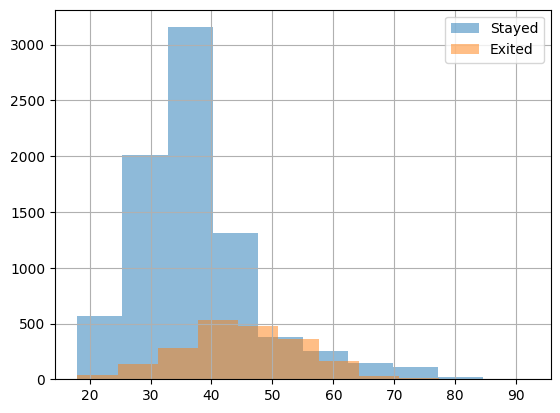

In [ ]:
import matplotlib.pyplot as plt

df[df['Exited'] == 0]['Age'].hist(alpha=0.5)
df[df['Exited'] == 1]['Age'].hist(alpha=0.5)
plt.legend(['Stayed', 'Exited'])
plt.show()